# Step 6: Neural Network & PyTorch

In [319]:
# 追加ライブラリ
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation

## tensor.py

In [320]:
import torch

x = torch.tensor(5.0, requires_grad=True)
y = 3 * x ** 2
print(y)

y.backward()    # 逆伝播を計算   
print(x.grad)   # dy/dx = 6 * x = 30 となるはず

tensor(75., grad_fn=<MulBackward0>)
tensor(30.)


## Rosenbrock function

$$
y = 100(x_1-x_0^2)^2 + (x_0-1)^2
$$

In [321]:
import numpy as np

def rosenbrock(x0, x1):
    y = 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2
    return y

x0 = np.linspace(-2, 2, 400)
x1 = np.linspace(-1, 3, 400)
x0_grid, x1_grid = np.meshgrid(x0, x1)
y_grid = rosenbrock(x0_grid, x1_grid)

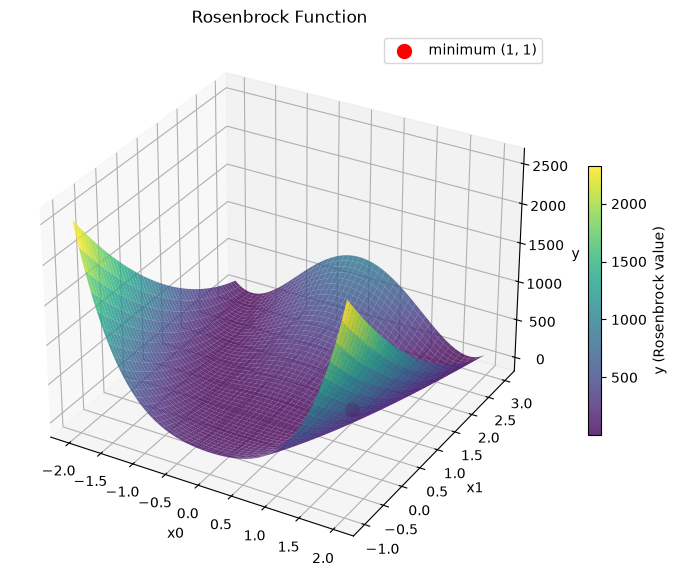

In [322]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis', alpha=0.8)
fig.colorbar(surf, ax=ax, shrink=0.5, label='y (Rosenbrock value)')

ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()

ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('y')
ax.set_title('Rosenbrock Function')
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


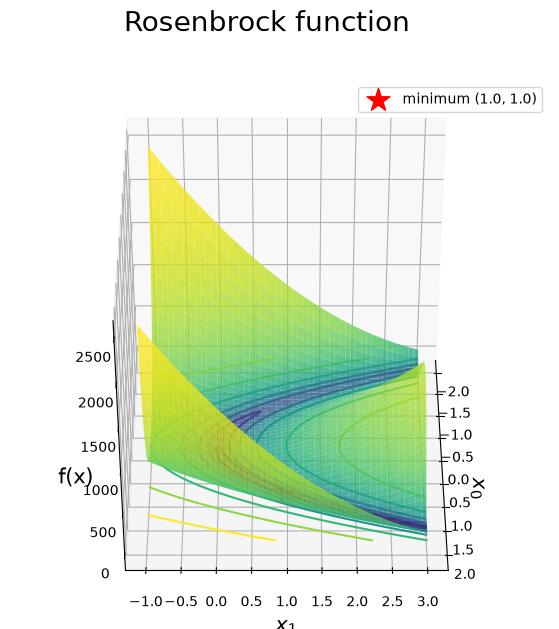

In [323]:
# 水平方向の角度として利用する値を指定
h_vals = np.arange(0.0, 360.0, step=5.0)

# フレーム数を設定
frame_num = len(h_vals)

# 図を初期化
fig = plt.figure(figsize=(10, 7), facecolor='white')
ax = fig.add_subplot(projection='3d') # 3D用の設定
fig.suptitle('Rosenbrock function', fontsize=20)
    
# 作図処理を関数として定義
def update(i):
    # 前フレームのグラフを初期化
    plt.cla()
    
    # i番目の角度を取得
    h = h_vals[i]
    
    # ローゼンブロック関数の曲面図を描画
    ax.contour(x0_grid, x1_grid, y_grid, 
               norm=LogNorm(), levels=levs, offset=0.0) # 等高線
    ax.plot_surface(x0_grid, x1_grid, y_grid, 
                    norm=LogNorm(), cmap='viridis', alpha=0.8) # 曲面
    ax.scatter(1.0, 1.0, rosenbrock(1.0, 1.0), 
               marker='*', s=300, c='red',
               label='minimum (1.0, 1.0)') # 最小値
    ax.legend(loc='upper right')
    ax.set_xlabel('$x_0$', fontsize=15)
    ax.set_ylabel('$x_1$', fontsize=15)
    ax.set_zlabel('f(x)', fontsize=15)
    ax.set_box_aspect(aspect=(1, 1, 1))
    ax.view_init(elev=40, azim=h) # 表示角度

# gif画像を作成
ani = FuncAnimation(fig=fig, func=update, frames=frame_num, interval=100)

# gif画像を保存
ani.save('rosenbrock.gif')

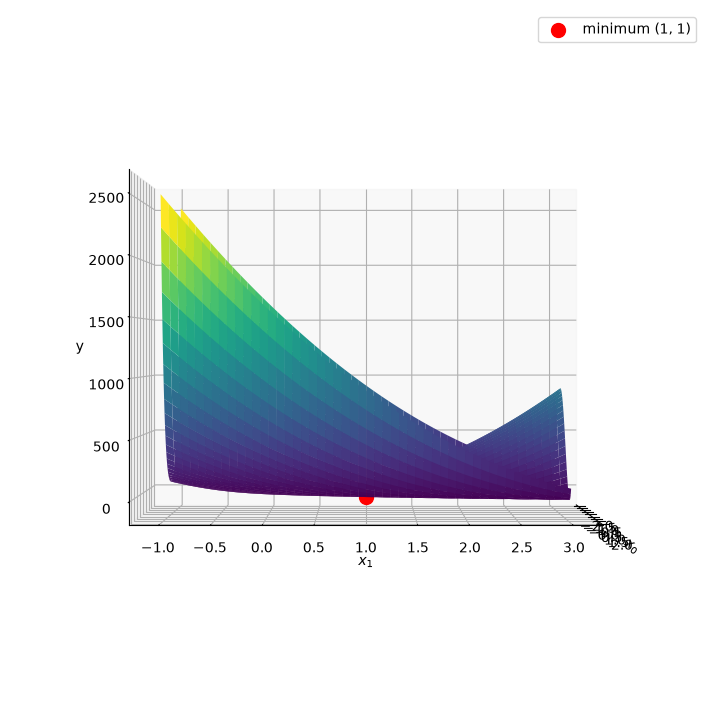

In [324]:
from matplotlib.colors import LogNorm

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis') # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.view_init(elev=0, azim=0) # 表示アングル
plt.show()

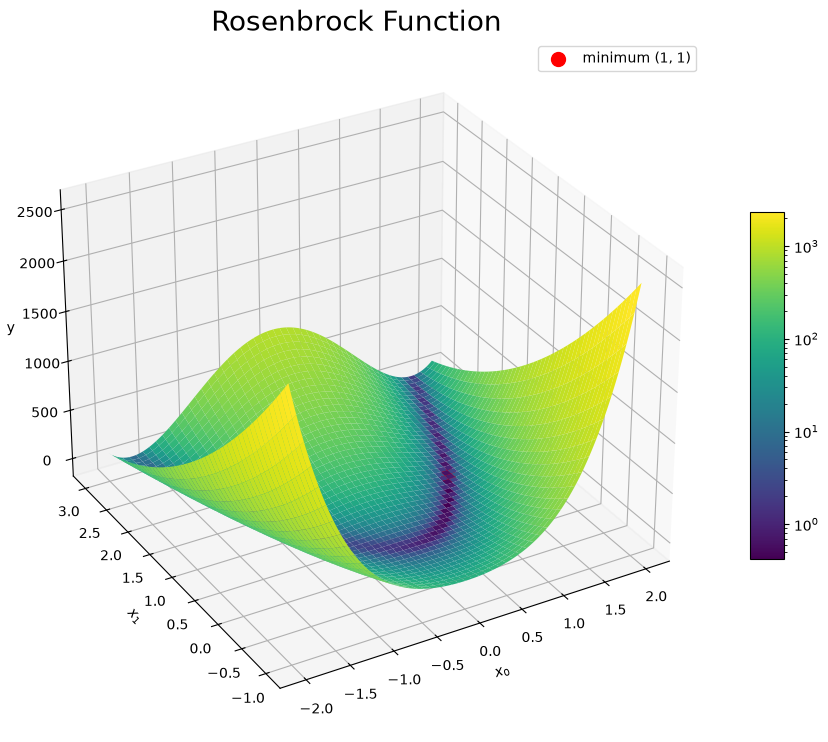

In [325]:
from matplotlib.colors import LogNorm

# 3Dプロットを作図
fig = plt.figure(figsize=(12, 9)) # 図の準備
ax = fig.add_subplot(projection='3d') # 3Dプロットの準備
surf = ax.plot_surface(x0_grid, x1_grid, y_grid, cmap='viridis', norm=LogNorm()) # 曲面プロット
ax.scatter(1, 1, 0, color='red', s=100, zorder=5, label='minimum (1, 1)')
ax.legend()
ax.set_xlabel('$x_0$') # x軸ラベル
ax.set_ylabel('$x_1$') # y軸ラベル
ax.set_zlabel('y') # z軸ラベル
ax.set_title('Rosenbrock Function', fontsize=20) # タイトル
fig.colorbar(surf, shrink=0.5, aspect=10)
ax.view_init(elev=30, azim=240) # 表示アングル
plt.show()

## gradient.py

In [326]:
import torch

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

y = rosenbrock(x0, x1)
y.backward()
print(x0.grad, x1.grad)

tensor(-2.) tensor(400.)


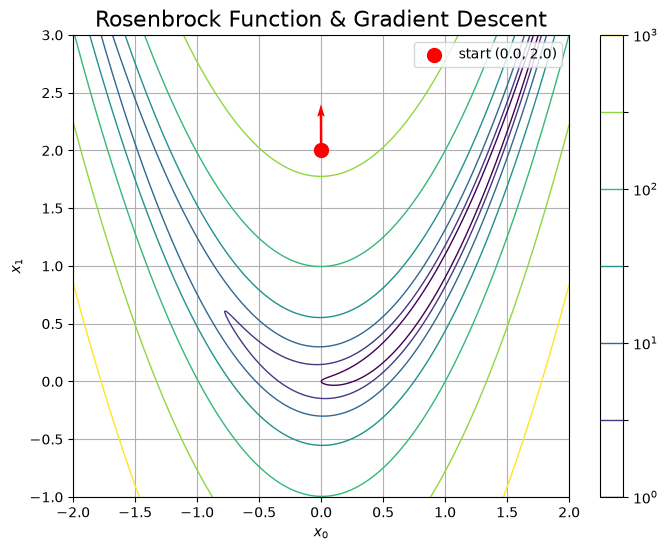

In [327]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch

start_point = (0.0, 2.0)  # 初期点

# 勾配を計算 (PyTorchで自動微分)
x0_t = torch.tensor(start_point[0], requires_grad=True)
x1_t = torch.tensor(start_point[1], requires_grad=True)
y_t = rosenbrock(x0_t, x1_t)
y_t.backward()
g0 = x0_t.grad.item()  
g1 = x1_t.grad.item()  

# 矢印の長さを正規化 (プロット範囲に合わせてスケール)
g_norm = (g0**2 + g1**2) ** 0.5
scale = 0.4  # 表示上の矢印の長さ (軸単位)
dq0 = scale * g0 / g_norm
dq1 = scale * g1 / g_norm

# 等高線
levs = 10**np.arange(0., 3.5, 0.5)

# プロット
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contour(x0_grid, x1_grid, y_grid, levels=levs, norm=LogNorm(), cmap='viridis', linewidths=1)
plt.colorbar(contour)

ax.scatter(start_point[0], start_point[1], color='red', s=100, zorder=5, label='start ({}, {})'.format(start_point[0], start_point[1]))
ax.quiver(start_point[0], start_point[1], dq0, dq1, angles='xy', scale_units='xy', scale=1,
          color='red', width=0.005, zorder=6)
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Rosenbrock Function & Gradient Descent', fontsize=16)
ax.legend()
plt.grid()
plt.show()

## 勾配法を用いた関数の最小点の探索
$$
x_0 \leftarrow x_0 - \eta \cfrac{\partial y}{\partial x_0}
$$
$$
x_1 \leftarrow x_1 - \eta \cfrac{\partial y}{\partial x_1}
$$

In [363]:
lr = 0.001  # learning rate
iters = 10000  # iteration count

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

history = [(x0.item(), x1.item())]  # 初期点を履歴に追加

# 勾配法の更新処理
def run_gradient(x0, x1, lr, iters, history, display_interval=True):
    for i in range(iters):
        if i % 1000 == 0 and display_interval:
            print(f"{x0.item():.7f}, {x1.item():.7f}") # float32 の仮数部は 23 bit なので有効数字は約7桁(2^23 ≈ 10^7.2)
        y = rosenbrock(x0, x1)

        y.backward()

        x0.data -= lr * x0.grad.data
        x1.data -= lr * x1.grad.data

        x0.grad.zero_()
        x1.grad.zero_()

        history.append((x0.item(), x1.item()))

run_gradient(x0, x1, lr, iters, history)
print(f"{x0.item():.7f}, {x1.item():.7f}") 

0.0000000, 2.0000000
0.6837119, 0.4659528
0.8263181, 0.6820318
0.8947841, 0.8001903
0.9334872, 0.8711215
0.9569893, 0.9156519
0.9718162, 0.9443122
0.9813805, 0.9630323
0.9876351, 0.9753732
0.9917611, 0.9835569
0.9944981, 0.9890044


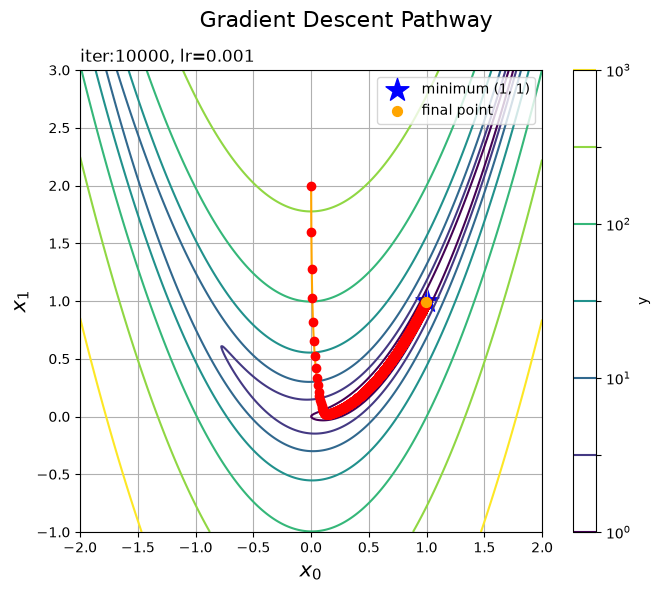

In [364]:
xs, ys = zip(*history)

def display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
        fig.suptitle('Gradient Descent Pathway', fontsize=16)
    cnt = ax.contour(x0_grid, x1_grid, y_grid, norm=LogNorm(), levels=levs)
    ax.scatter(1.0, 1.0, marker='*', s=300, c='blue', label='minimum (1, 1)')
    ax.plot(xs, ys, c='orange', marker='o', mfc='red', mec='red')
    ax.scatter(xs[-1], ys[-1], marker='o', s=50, c='orange', edgecolors='orange', zorder=5, label='final point')
    ax.set_xlabel('$x_0$', fontsize=15)
    ax.set_ylabel('$x_1$', fontsize=15)
    ax.set_title('iter:' + str(iters) + ', lr=' + str(lr), loc='left')
    plt.colorbar(cnt, ax=ax, label='y')
    ax.grid()
    ax.set_aspect('equal')
    ax.legend()
    if standalone:
        plt.show()

display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr)

## 勾配法(lrによる比較)

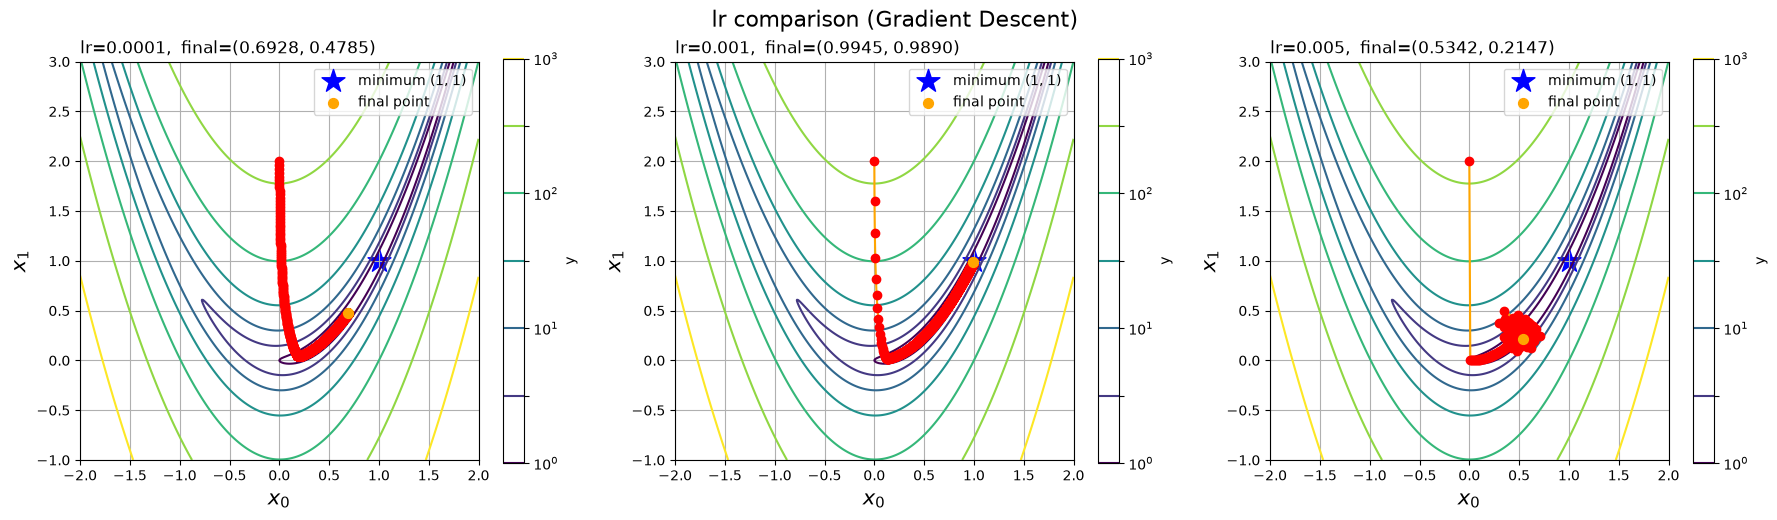

In [368]:
import torch
from matplotlib.colors import LogNorm

start_point = (0.0, 2.0)  # 初期点

lr_list = [0.0001, 0.001, 0.005]
iters = 10000

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
fig.suptitle('lr comparison (Gradient Descent)', fontsize=16)

for ax, lr in zip(axes, lr_list):
    x0 = torch.tensor(start_point[0], requires_grad=True)
    x1 = torch.tensor(start_point[1], requires_grad=True)
    history = [(x0.item(), x1.item())]
    run_gradient(x0, x1, lr, iters, history, display_interval=False)
    xs, ys = zip(*history)
    display_gradient_descent_pathway(xs, ys, x0_grid, x1_grid, y_grid, levs, iters, lr, ax=ax)
    ax.set_title(f'lr={lr},  final=({xs[-1]:.4f}, {ys[-1]:.4f})', loc='left')

plt.tight_layout()
plt.show()

## regression.py

In [331]:
import torch


torch.manual_seed(42)
x = torch.rand(100, 1)
y = 5 + 2 * x + torch.rand(100, 1)

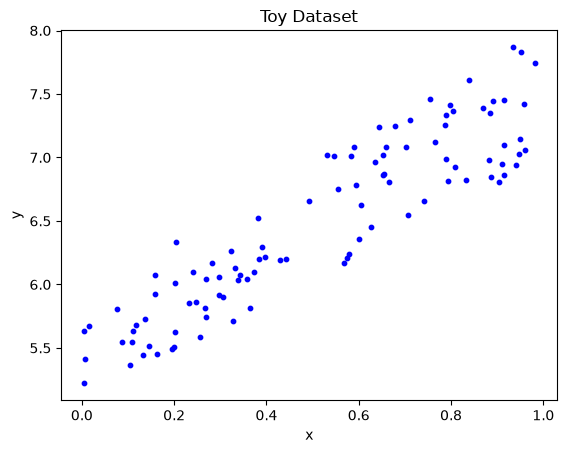

In [332]:
plt.scatter(x.numpy(), y.numpy(), color='blue', label='data', s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Toy Dataset')
plt.show()

42.5653076171875
0.21618643403053284
0.09786500781774521
0.09215116500854492
0.08800803869962692
0.08484316617250443
0.08242511004209518
0.08057764172554016
0.07916611433029175
0.07808766514062881
0.07733648270368576
====
W = 2.2837204933166504
b = 5.304651737213135


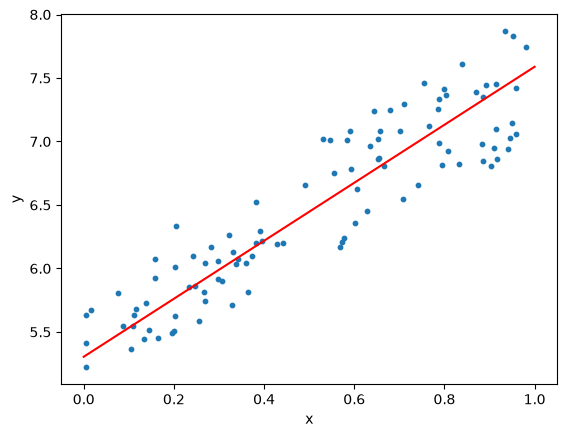

In [333]:
W = torch.zeros((1, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def predict(x):
    y = x @ W + b
    return y

def mean_squared_error(x0, x1):
    diff = x0 - x1
    N = len(diff)
    return torch.sum(diff ** 2) / N

lr = 0.1
iters = 100

for i in range(iters):
    y_hat = predict(x)
    loss = mean_squared_error(y, y_hat)

    loss.backward()

    W.data -= lr * W.grad.data
    b.data -= lr * b.grad.data

    W.grad.zero_()
    b.grad.zero_()

    if i % 10 == 0: # print every 10 iterations
        print(loss.item())

print(loss.item())
print('====')
print('W =', W.item())
print('b =', b.item())


# plot
import matplotlib.pyplot as plt
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
x = torch.tensor([[0.0], [1.0]])
y = W.detach().numpy() * x.detach().numpy() + b.detach().numpy()
plt.plot(x, y, color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## neuralnet.py

0.7643452286720276
0.23656319081783295
0.2322607785463333
0.22441406548023224
0.21026146411895752
0.17957882583141327
0.11798450350761414
0.08470459282398224
0.08017464727163315
0.07966045290231705
0.07946839183568954


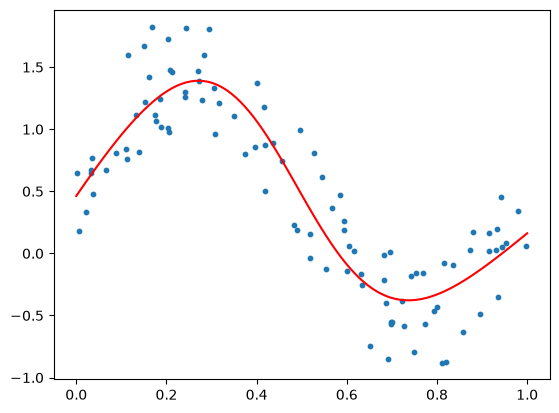

In [334]:
import torch
import torch.nn as nn
import torch.nn.functional as F


torch.manual_seed(0)
x = torch.rand(100, 1)
y = torch.sin(2 * torch.pi * x) + torch.rand(100, 1)

# model
class Model(nn.Module):
    def __init__(self, input_size=1, hidden_size= 10, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        y = self.linear1(x)
        y = F.sigmoid(y)
        y = self.linear2(y)
        return y


lr = 0.2
iters = 10000

model = Model()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

for i in range(iters):
    y_pred = model(x)
    loss = F.mse_loss(y, y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 1000 == 0:
        print(loss.item())

print(loss.item())

# plot
import matplotlib.pyplot as plt
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=10)
x = torch.linspace(0, 1, 100).reshape(-1, 1)
y = model(x).detach().numpy()
plt.plot(x, y, color='red')
plt.show()

## vision.py

size: 60000
type: <class 'PIL.Image.Image'>
label: 5


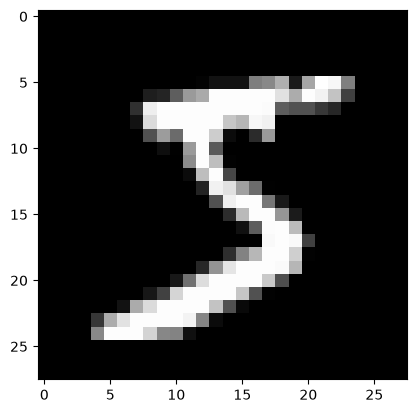

type: <class 'torch.Tensor'>
shape: torch.Size([1, 28, 28])
x shape: torch.Size([32, 1, 28, 28])
label shape: torch.Size([32])


In [335]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


## ==== MNIST ====
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=None,
    download=True
)

x, label = dataset[0]

print('size:', len(dataset))  # size: 60000
print('type:', type(x))  # type: <class 'PIL.Image.Image'>
print('label:', label)  # label: 5

plt.imshow(x, cmap='gray')
plt.show()


# ==== preprocess ====
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

x, label = dataset[0]
print('type:', type(x))  # type: <class 'torch.Tensor'>
print('shape:', x.shape)  # shape: torch.Size([1, 28, 28])


# ==== DataLoader ====
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True)

for x, label in dataloader:
    print('x shape:', x.shape)  # shape: torch.Size([32, 1, 28, 28])
    print('label shape:', label.shape)  # shape: torch.Size([32])
    break